# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HamzaMohamed25/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

*Loads the 1 May decision-point frame from ML-04 (features Feb-Apr 2026, label `y_decline_may`). If the cached file is missing, the cell rebuilds it from the warehouse (needs `HF_TOKEN`). June 2026 is not touched until section 1 has frozen every setting.*

In [1]:
# Setup | load the decision-point frame; build it from the warehouse only if it is not cached (features Feb-Apr 2026, label May 2026; June is never loaded)
import gc, json, os
import numpy as np, pandas as pd

FRAME = "work/outputs/frame_dp_2026-05-01.parquet"
os.makedirs("work/outputs", exist_ok=True)

def hf_token():
    try:
        from google.colab import userdata          # Colab: Secrets panel
        return userdata.get("HF_TOKEN")
    except Exception:
        return os.environ.get("HF_TOKEN")          # local run: environment variable

if os.path.exists(FRAME):
    print("Using the cached frame:", FRAME)
else:
    # ML-04 v2 | Decision-point frame: features Feb-Apr 2026, label May 2026. June stays sealed (never loaded).
    import gc, json, os
    import numpy as np, pandas as pd

    HF = {"token": hf_token()}
    HF_BASE = "hf://datasets/FlyRank/internship-warehouse"
    FEAT_MONTHS, LABEL_MONTH = ["2026-02", "2026-03", "2026-04"], "2026-05"
    MIN_IMPR_WINDOW, MIN_CLICKS_APR, DROP_RATIO = 1000, 10, 0.80      # contract thresholds: frozen before any model
    KEYS = ["client_hash_id", "content_hash_id"]
    COLS = ["report_date", *KEYS, "gsc_clicks", "gsc_impressions", "gsc_avg_position"]
    assert LABEL_MONTH != "2026-06" and "2026-06" not in FEAT_MONTHS, "June is the sealed test month"

    def month_agg(m):
        """One partition -> one row per (client, content). Loads only needed columns; frees RAM right after."""
        path = f"{HF_BASE}/fact_content_daily_performance/month={m}/"
        try:
            d = pd.read_parquet(path, columns=COLS, storage_options=HF)
        except Exception:
            from huggingface_hub import HfFileSystem
            import pyarrow.parquet as pq
            fs = HfFileSystem(token=HF["token"])
            f = fs.ls(f"datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={m}", detail=False)[0]
            print("Actual schema:", pq.read_schema(f, filesystem=fs).names); raise
        dates = pd.to_datetime(d["report_date"])
        win = (dates.min().date(), dates.max().date(), len(d))
        impr = d["gsc_impressions"].fillna(0)
        pos = d["gsc_avg_position"].where(d["gsc_avg_position"] > 0)            # 0/negative = no data, not rank 0
        d = d.assign(clicks=d["gsc_clicks"].fillna(0), impr=impr,
                     pos_x_impr=(pos * impr).fillna(0), impr_pos=impr.where(pos.notna(), 0),
                     active=(impr > 0).astype("int16"))
        g = d.groupby(KEYS, observed=True).agg(clicks=("clicks", "sum"), impr=("impr", "sum"),
                                               pos_x_impr=("pos_x_impr", "sum"), impr_pos=("impr_pos", "sum"),
                                               active_days=("active", "sum")).reset_index()
        del d; gc.collect()
        return g, win

    # 1) Aggregate each month separately (daily grain -> content grain), check windows land inside their month
    frames, windows = {}, {}
    for m in FEAT_MONTHS + [LABEL_MONTH]:
        frames[m], windows[m] = month_agg(m)
        assert str(windows[m][0]).startswith(m) and str(windows[m][1]).startswith(m), f"{m} partition has dates outside its month"
        print(f"{m}: daily rows={windows[m][2]:,} | {windows[m][0]} -> {windows[m][1]} | contents={len(frames[m]):,}")

    # 2) Feature frame from Feb-Apr ONLY (nine features, all knowable on 2026-05-01)
    f = None
    for m in FEAT_MONTHS:
        part = frames[m].rename(columns={c: f"{c}_{m}" for c in ["clicks", "impr", "pos_x_impr", "impr_pos", "active_days"]})
        f = part if f is None else f.merge(part, on=KEYS, how="outer")
    num = [c for c in f.columns if c not in KEYS]
    f[num] = f[num].fillna(0)                                             # absent row in a month = no search rows that month
    S = lambda p: sum(f[f"{p}_{m}"] for m in FEAT_MONTHS)
    f["impressions_total"], f["clicks_total"] = S("impr"), S("clicks")
    f["impressions_apr"], f["clicks_apr"], f["clicks_feb"] = f["impr_2026-04"], f["clicks_2026-04"], f["clicks_2026-02"]
    f["momentum_apr_vs_feb"] = np.log1p(f["clicks_apr"]) - np.log1p(f["clicks_feb"])
    f["ctr"] = np.where(f["impressions_total"] > 0, f["clicks_total"] / f["impressions_total"], np.nan)
    f["weighted_position"] = np.where(S("impr_pos") > 0, S("pos_x_impr") / S("impr_pos").replace(0, np.nan), np.nan)  # sum(pos*impr)/sum(impr), not a mean of daily means
    f["active_days"] = S("active_days")
    FEATURES = ["impressions_total", "clicks_total", "impressions_apr", "clicks_apr", "clicks_feb",
                "momentum_apr_vs_feb", "ctr", "weighted_position", "active_days"]
    f = f[KEYS + FEATURES]

    # 3) Label from May ONLY: decline = May clicks < 80% of April clicks. Label ingredients are never features.
    may = frames[LABEL_MONTH][KEYS + ["clicks"]].rename(columns={"clicks": "clicks_may"})
    n_before_eligibility = len(f)
    f = f[(f["impressions_total"] >= MIN_IMPR_WINDOW) & (f["clicks_apr"] >= MIN_CLICKS_APR)]   # eligibility, decided at the decision point
    f = f.merge(may, on=KEYS, how="left")
    missing_in_may = int(f["clicks_may"].isna().sum())
    f["clicks_may"] = f["clicks_may"].fillna(0)                           # not seen in May -> 0 clicks -> counts as decline (stated in contract)
    f["y_decline_may"] = (f["clicks_may"] < DROP_RATIO * f["clicks_apr"]).astype(int)
    LABEL_INGREDIENTS = ["clicks_may"]                                    # kept ONLY to build/audit the label
    frame = f.reset_index(drop=True)

    # 4) Contract checks (queries, not claims)
    assert not frame.duplicated(KEYS).any(), "grain broken: (client, content) must be unique"
    assert not set(LABEL_INGREDIENTS) & set(FEATURES), "label ingredient leaked into features"
    assert set(KEYS).isdisjoint(FEATURES), "IDs are grouping keys, never features"
    share = frame["client_hash_id"].value_counts(normalize=True)
    base_rate = float(frame["y_decline_may"].mean())
    print(f"\nBefore eligibility: {n_before_eligibility:,} | Eligible rows: {len(frame):,} | Clients: {frame['client_hash_id'].nunique()}")
    print(f"Base rate (decline in May): {base_rate:.3f} | Not seen in May (counted as decline): {missing_in_may:,}")
    print(f"Largest client share of rows: {share.iloc[0]:.1%} | Top-5 clients: {share.head(5).sum():.1%}")
    print("Per-client base rate spread (min / median / max, clients with >=30 rows):")
    pc = frame.groupby("client_hash_id")["y_decline_may"].agg(["mean", "size"]); pc = pc[pc["size"] >= 30]["mean"]
    print(f"  {pc.min():.2f} / {pc.median():.2f} / {pc.max():.2f}  over {len(pc)} clients")
    print("Missing in features (share):"); print(frame[FEATURES].isna().mean().round(3).to_string())

    # 5) Receipt (commit this JSON), cache the frame locally (do NOT commit the parquet)
    os.makedirs("work/outputs", exist_ok=True)
    frame.to_parquet("work/outputs/frame_dp_2026-05-01.parquet", index=False)
    json.dump({"decision_point": "2026-05-01", "feature_months": FEAT_MONTHS, "label_month": LABEL_MONTH,
               "min_impr_window": MIN_IMPR_WINDOW, "min_clicks_apr": MIN_CLICKS_APR, "drop_ratio": DROP_RATIO,
               "rows_before_eligibility": int(n_before_eligibility), "rows": int(len(frame)),
               "clients": int(frame["client_hash_id"].nunique()), "base_rate": round(base_rate, 4),
               "not_seen_in_may": missing_in_may, "features": FEATURES, "label": "y_decline_may",
               "group_key": "client_hash_id", "sealed_month": "2026-06", "release": "v20260703"},
              open("work/outputs/data_contract_v2.json", "w"), indent=2)
    print("\nSaved: work/outputs/data_contract_v2.json (commit) + frame parquet (cache only)")

2026-02: daily rows=7,355,108 | 2026-02-01 -> 2026-02-28 | contents=321,546
2026-03: daily rows=9,841,378 | 2026-03-01 -> 2026-03-31 | contents=331,437
2026-04: daily rows=10,424,730 | 2026-04-01 -> 2026-04-30 | contents=362,172
2026-05: daily rows=11,687,376 | 2026-05-01 -> 2026-05-31 | contents=389,153

Before eligibility: 380,147 | Eligible rows: 16,513 | Clients: 36
Base rate (decline in May): 0.416 | Not seen in May (counted as decline): 0
Largest client share of rows: 26.1% | Top-5 clients: 71.9%
Per-client base rate spread (min / median / max, clients with >=30 rows):
  0.03 / 0.38 / 0.75  over 17 clients
Missing in features (share):
impressions_total      0.0
clicks_total           0.0
impressions_apr        0.0
clicks_apr             0.0
clicks_feb             0.0
momentum_apr_vs_feb    0.0
ctr                    0.0
weighted_position      0.0
active_days            0.0

Saved: work/outputs/data_contract_v2.json (commit) + frame parquet (cache only)


## 1. Ranked actions + reason codes

**The playbook in one line.** The frozen, audited ML-07 rule supplies the **reason**, and the Logistic Regression supplies the **order**. A person decides what to do. Nothing here edits a page.

**Decision point.** The queue is built at **1 June 2026** from March, April and May. The model is trained only at the 1 May decision point (features Feb-Apr, label May), and June is read **once**, after everything below is frozen, to check the queue (the sealed month). Settings, thresholds and archetype cut-offs are printed before June is loaded.

**Actions and reason codes.**

| Action | When | Reason code | What a person does |
|---|---|---|---|
| `verify_spike_then_review` | The rule flags the page: the latest month is at least 2x the average of the two months before, and the page had at least 10 clicks in each of those two months | `click_surge_vs_prior` | Check for a tracking or campaign artifact, a seasonal topic, or a climb that is still going. Then decide. |
| `investigate_quiet_risk` | The model score is in the top 50 but the rule has no flag | `model_score_high_no_rule_flag` | Look for a reason. The score alone is not a reason. |
| `monitor_only` | Established pages that are not in the queue | none | Keep watching. No edit. |
| not on the queue | Fewer than 10 clicks in the first or the middle month (new or thin history) | `thin_history` | Not eligible. |

**Ordering.** Among eligible pages the Logistic Regression score orders the top 50. Exact ties are broken by a seeded hash, so the list repeats on every run. Each row carries a **confidence note**: *low* when the jump is more than 7x or the latest month has fewer than 30 clicks, otherwise *medium*. It is never *high*, because the ranking is weak (AUC about 0.57).

**Archetype to action mapping.** This lane scores pages, so there is no clustering. The archetypes below are rule-based segments computed from features only, with cut-offs fixed before June is read. The observed next-month decline rate for each archetype is printed in the cell below.

| Archetype | Definition | Action |
|---|---|---|
| 1. New or thin history | fewer than 10 clicks in the first or middle month | not on the queue |
| 2. Surge on an established page | enough history, latest month at least 2x the prior average | `verify_spike_then_review` |
| 3. Established, steady or rising | enough history, latest month between 0.8x and 2x | `monitor_only` (or `investigate_quiet_risk` if the model puts it in the top 50) |
| 4. Established, dipping | enough history, latest month below 0.8x | `monitor_only` (or `investigate_quiet_risk` if the model puts it in the top 50) |

**The decay / refresh insight (observed, directional, from ML-07 to ML-09).**

- **A one-month dip is not decay.** Pages whose clicks fell two months in a row declined in the next month *less* often than average (33.9% against a 38.5% base rate in ML-07). Pages that dipped usually bounced back.
- **The strongest short-term signal is a surge, and it reverts.** Pages whose latest month was at least twice their earlier average declined next month 44.2% of the time, against about 36% for flat or falling pages. That looks like reversion after a spike, not decay.
- **The declines the model misses look like slow decay.** In ML-08 the missed declines were bigger and steadier pages (median 31 April clicks, 89 active days, a flat ratio of 1.06).
- **So the queue should not trigger a refresh from a one-month drop.** It sends a person to verify spikes and to investigate model-flagged risk. A real decay rule would need a longer window (for example three months of sustained decline on an established page). This data, with one decision point per month, cannot validate that rule. It is a proposal, not a finding.

In [3]:
# 1) Freeze the plan, train at the 1 May point, build the 1 June queue, assign archetypes
import json, platform
import numpy as np, pandas as pd, sklearn
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

SEED, K_MAIN = 42, 50
KEYS, LABEL, LABEL_NEXT = ["client_hash_id", "content_hash_id"], "y_decline_may", "y_decline_next"
FEATURES = ["impressions_total", "clicks_total", "impressions_apr", "clicks_apr", "clicks_feb",
            "momentum_apr_vs_feb", "ctr", "weighted_position", "active_days"]
COUNTS = ["impressions_total", "clicks_total", "impressions_apr", "clicks_apr", "clicks_feb"]
MIN_RATIO, HISTORY_FLOOR, BLOCK_COPIES = 2.0, 10, 20                 # frozen ML-07 rule settings
DIP_CUT, SURGE_EXTREME, LOW_CLICKS = 0.8, 7.0, 30                    # archetype and confidence cut-offs, fixed now
VEC = ["clicks_feb", "clicks_mar", "clicks_apr", "impressions_apr", "weighted_position", "active_days"]
FRAME_JUN = "work/outputs/frame_dp_2026-06-01.parquet"
os.makedirs("work/figures", exist_ok=True)
A1, A2, A3, A4 = "1 new or thin history", "2 surge on an established page", "3 established, steady or rising", "4 established, dipping"
print("FROZEN BEFORE JUNE IS READ")
print(f"  model: Logistic Regression ({len(FEATURES)} contract features, log1p on counts, scaled), trained ONLY on the 1 May decision point (features Feb-Apr, label May)")
print(f"  rule: ML-07 (latest month >= {MIN_RATIO}x the earlier two-month average, >= {HISTORY_FLOOR} clicks in each earlier month) | K = {K_MAIN} | seed {SEED}")
print(f"  archetype cut-offs: history floor {HISTORY_FLOOR}, surge {MIN_RATIO}x, dip below {DIP_CUT}x | extreme jump above {SURGE_EXTREME}x | low confidence below {LOW_CLICKS} clicks")
print(f"  versions: python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}\n")

def add_derived(f):
    f = f.copy()
    f["clicks_mar"] = (f["clicks_total"] - f["clicks_apr"] - f["clicks_feb"]).clip(lower=0)      # middle month of the feature window
    prior = (f["clicks_feb"] + f["clicks_mar"]) / 2
    f["ratio_apr"] = f["clicks_apr"] / prior.where(prior > 0)                                    # latest month vs the average of the two before
    return f
def drop_block(f):
    blk = f.groupby(VEC, dropna=False)["content_hash_id"].transform("size") >= BLOCK_COPIES      # identical rows: not independent evidence
    return f[~blk].reset_index(drop=True), int(blk.sum())
def tiebreak(f): return pd.util.hash_pandas_object(f["content_hash_id"].astype(str) + f"|{SEED}", index=False).to_numpy()
def rule_score(f):
    flag = (f["ratio_apr"] >= MIN_RATIO) & (f["clicks_feb"] >= HISTORY_FLOOR) & (f["clicks_mar"] >= HISTORY_FLOOR)
    strength = (np.log2(f["ratio_apr"].clip(lower=1)) / 3).clip(0, 1)
    return np.where(flag, 100 * strength * f["impressions_apr"].rank(pct=True), 0.0).round(4)
def archetype(f):
    hist = (f["clicks_feb"] >= HISTORY_FLOOR) & (f["clicks_mar"] >= HISTORY_FLOOR); r = f["ratio_apr"]
    return np.select([~hist, hist & (r >= MIN_RATIO), hist & (r >= DIP_CUT)], [A1, A2, A3], default=A4)
def make_lr():
    return make_pipeline(ColumnTransformer([("counts", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), COUNTS),
                                            ("others", StandardScaler(), [c for c in FEATURES if c not in COUNTS])]), LogisticRegression(max_iter=2000))
def prec_at_k(y_, s_, tb_, k):
    o = np.lexsort((tb_, -s_)); return float(y_[o][:k].mean())

# Training population: the 1 May decision point, same analysis frame as ML-07 to ML-09
dev, n_block_dev = drop_block(add_derived(pd.read_parquet(FRAME)))
dev["_tb"], dev["archetype"] = tiebreak(dev), archetype(dev)
lr = make_lr().fit(dev[FEATURES], dev[LABEL])

# Scoring population: the 1 June decision point (features March-May). Feature names keep their ML-04 names but mean
# "latest month" (impressions_apr, clicks_apr), "middle month" (clicks_mar) and "first month" (clicks_feb).
def agg_month(m):
    d = pd.read_parquet(f"hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={m}/", columns=["report_date", *KEYS, "gsc_clicks", "gsc_impressions", "gsc_avg_position"], storage_options={"token": hf_token()})
    dates = pd.to_datetime(d["report_date"]); assert str(dates.min().date()).startswith(m) and str(dates.max().date()).startswith(m), f"{m}: dates outside the month"
    impr = d["gsc_impressions"].fillna(0); pos = d["gsc_avg_position"].where(d["gsc_avg_position"] > 0)
    d = d.assign(clicks=d["gsc_clicks"].fillna(0), impr=impr, pos_x_impr=(pos * impr).fillna(0), impr_pos=impr.where(pos.notna(), 0), active=(impr > 0).astype("int16"))
    return d.groupby(KEYS, observed=True).agg(clicks=("clicks", "sum"), impr=("impr", "sum"), pos_x_impr=("pos_x_impr", "sum"), impr_pos=("impr_pos", "sum"), active_days=("active", "sum")).reset_index()
def build_dp(feat_months, label_month):
    first, last = feat_months[0], feat_months[-1]
    f = None
    for m in feat_months:
        part = agg_month(m).rename(columns={c: f"{c}_{m}" for c in ["clicks", "impr", "pos_x_impr", "impr_pos", "active_days"]})
        f = part if f is None else f.merge(part, on=KEYS, how="outer")
    f = f.fillna(0); S = lambda p: sum(f[f"{p}_{m}"] for m in feat_months)
    out = f[KEYS].copy()
    out["impressions_total"], out["clicks_total"] = S("impr"), S("clicks")
    out["impressions_apr"], out["clicks_apr"], out["clicks_feb"] = f[f"impr_{last}"], f[f"clicks_{last}"], f[f"clicks_{first}"]
    out["momentum_apr_vs_feb"] = np.log1p(out["clicks_apr"]) - np.log1p(out["clicks_feb"])
    out["ctr"] = np.where(out["impressions_total"] > 0, out["clicks_total"] / out["impressions_total"], np.nan)
    out["weighted_position"] = np.where(S("impr_pos") > 0, S("pos_x_impr") / S("impr_pos").replace(0, np.nan), np.nan)
    out["active_days"] = S("active_days")
    out = out[(out["impressions_total"] >= 1000) & (out["clicks_apr"] >= 10)].reset_index(drop=True)     # same eligibility as ML-04
    out["clicks_next"], out[LABEL_NEXT] = np.nan, np.nan
    try:                                                                                              # the sealed month is read here, once
        nxt = agg_month(label_month)[KEYS + ["clicks"]].rename(columns={"clicks": "_n"})
        out = out.drop(columns=["clicks_next", LABEL_NEXT]).merge(nxt, on=KEYS, how="left")
        out["clicks_next"] = out["_n"].fillna(0); out = out.drop(columns="_n")
        out[LABEL_NEXT] = (out["clicks_next"] < 0.8 * out["clicks_apr"]).astype(int)
    except Exception as e:
        print("LABEL MONTH NOT READABLE (the queue is still built; the post-label checks are skipped):", type(e).__name__, str(e)[:120])
    return out
if not os.path.exists(FRAME_JUN):
    build_dp(["2026-03", "2026-04", "2026-05"], "2026-06").to_parquet(FRAME_JUN, index=False)
jun, n_block_jun = drop_block(add_derived(pd.read_parquet(FRAME_JUN)))
june_ok = bool(jun[LABEL_NEXT].notna().all())
jun["_tb"], jun["archetype"] = tiebreak(jun), archetype(jun)
jun["lr_score"], jun["rule_score"] = lr.predict_proba(jun[FEATURES])[:, 1], rule_score(jun)
assert "clicks_next" not in FEATURES and LABEL_NEXT not in FEATURES, "the label month is never a feature"

# The queue: the model orders, the rule explains
elig = jun[jun["archetype"] != A1]
o = np.lexsort((elig["_tb"].to_numpy(), -elig["lr_score"].to_numpy()))
queue = elig.iloc[o[:K_MAIN]].copy(); queue.insert(0, "rank", np.arange(1, K_MAIN + 1))
flagged = queue["rule_score"] > 0
queue["action"] = np.where(flagged, "verify_spike_then_review", "investigate_quiet_risk")
queue["reason_code"] = np.where(flagged, "click_surge_vs_prior", "model_score_high_no_rule_flag")
queue["confidence"] = np.where((queue["ratio_apr"] > SURGE_EXTREME) | (queue["clicks_apr"] < LOW_CLICKS), "low", "medium")
queue["durable_climb"] = queue["clicks_mar"] >= 1.25 * queue["clicks_feb"]
queue["model_score"] = queue["lr_score"].round(4)

def evaluate(f):
    y_, tb_ = f[LABEL_NEXT].to_numpy().astype(int), f["_tb"].to_numpy()
    r = {"pages": int(len(f)), "base_rate": float(y_.mean())}
    for name, col in (("Logistic Regression", "lr_score"), ("Frozen rule", "rule_score")):
        s = f[col].to_numpy()
        r[name] = {"p10": prec_at_k(y_, s, tb_, 10), "p50": prec_at_k(y_, s, tb_, 50), "p100": prec_at_k(y_, s, tb_, 100),
                   "auc": float(roc_auc_score(y_, s)), "curve": {k: prec_at_k(y_, s, tb_, k) for k in range(10, 201, 10)}}
    return r
POP_ALL, POP_Q = "all contract pages", "queue population (new or thin history excluded)"
eval_jun = {POP_ALL: evaluate(jun), POP_Q: evaluate(elig)} if june_ok else {}

print(f"1 June decision point: {len(jun):,} pages | {jun['client_hash_id'].nunique()} clients | identical block excluded: {n_block_jun:,} | queue-eligible pages: {len(elig):,}")
print(f"Queue action mix: {queue['action'].value_counts().to_dict()} | confidence: {queue['confidence'].value_counts().to_dict()}")
print("\nTop 10 of the queue (clicks are March / April / May):")
for r in queue.head(10).itertuples():
    print(f"#{r.rank} [{r.action} | {r.reason_code}] confidence: {r.confidence} | model score {r.model_score:.3f} | {r.archetype}\n   clicks {r.clicks_feb:.0f} / {r.clicks_mar:.0f} / {r.clicks_apr:.0f} ({r.ratio_apr:.1f}x the earlier average), {r.impressions_apr:,.0f} impressions in May, position {r.weighted_position:.1f}")

tab = dev.groupby("archetype").agg(pages=(LABEL, "size"), next_month_decline_rate=(LABEL, "mean")).round(3)
print(f"\nArchetypes at the 1 May decision point (development data; base rate {dev[LABEL].mean():.3f}):"); print(tab.to_string())
if june_ok:
    tj = jun.groupby("archetype").agg(pages=(LABEL_NEXT, "size"), next_month_decline_rate=(LABEL_NEXT, "mean")).round(3)
    print(f"\nArchetypes at the 1 June decision point (sealed month read once; base rate {jun[LABEL_NEXT].mean():.3f}):"); print(tj.to_string())


FROZEN BEFORE JUNE IS READ
  model: Logistic Regression (9 contract features, log1p on counts, scaled), trained ONLY on the 1 May decision point (features Feb-Apr, label May)
  rule: ML-07 (latest month >= 2.0x the earlier two-month average, >= 10 clicks in each earlier month) | K = 50 | seed 42
  archetype cut-offs: history floor 10, surge 2.0x, dip below 0.8x | extreme jump above 7.0x | low confidence below 30 clicks
  versions: python 3.13.16 | numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1

1 June decision point: 19,259 pages | 37 clients | identical block excluded: 173 | queue-eligible pages: 11,026
Queue action mix: {'investigate_quiet_risk': 49, 'verify_spike_then_review': 1} | confidence: {'low': 41, 'medium': 9}

Top 10 of the queue (clicks are March / April / May):
#1 [investigate_quiet_risk | model_score_high_no_rule_flag] confidence: low | model score 0.845 | 4 established, dipping
   clicks 22 / 26 / 11 (0.5x the earlier average), 2,225 impressions in May, position 42.0
#

## 2. Intended use and limits

**Intended use.** A monthly decision-support list that helps a content strategist choose which 50 pages to look at first. It is not an automatic editor, not a detector of decay, and not evidence that a refresh helps.

**Cost / value thinking.** The review budget is 50 pages. The value of a batch is the number of pages that really declined next month in the list, compared with picking 50 pages at random: `50 x (precision@50 - base rate)` extra declining pages per batch. The cost is reviewer time. The cell below prints this arithmetic with its assumptions visible (the minutes per page is an **assumption** to replace with a real number). It is a descriptive scenario from one sealed month. It is not a forecast, and it says nothing about traffic recovery, which would need a controlled test.

**Limits (all observed in this work).**

- **One forward window at a time.** Evidence comes from April to May (ML-09) and from the sealed May to June check below. That is thin temporal evidence, not a walk-forward over many months.
- **The ranking is weak overall.** AUC is about 0.57 under the honest designs, and the spread across folds is 7 to 13 points at precision@50.
- **The result leans on click-level features** that sit close to the label (ML-09 ablation), and the broad ranking adds little inside page-size bands.
- **The portfolio is lopsided:** 36 clients, the top five hold 72% of the rows, and client base rates run from 3% to 75%.
- **The label is a proxy.** "Next-month clicks below 80% of the latest month" does not say why, and it partly reflects regression to the mean.
- **The base rate moves between months** (0.538 at the April decision point, 0.385 at the May one), so the scores order pages but are not calibrated probabilities. Calibration was not evaluated.
- **A block of 833 identical pages from one client is excluded.** The exclusion rule uses feature columns only.

In [4]:
# 2) Limits in numbers + cost / value arithmetic (assumptions visible)
print(f"Training frame (1 May point): {len(dev):,} pages | base rate {dev[LABEL].mean():.3f}")
print(f"Scoring frame (1 June point): {len(jun):,} pages | {jun['client_hash_id'].nunique()} clients | pages with new or thin history (not on the queue): {int((jun['archetype'] == A1).sum()):,} ({(jun['archetype'] == A1).mean():.1%})")
cs = queue["client_hash_id"].value_counts(normalize=True)
print(f"Queue: {queue['client_hash_id'].nunique()} clients | largest client share {cs.iloc[0]:.0%} | median clicks in May {queue['clicks_apr'].median():.0f} | rows with a low confidence note {int((queue['confidence'] == 'low').sum())} of {K_MAIN}")
if june_ok:
    pop = eval_jun[POP_Q]; b = pop["base_rate"]; p_lr, p_rule = pop["Logistic Regression"]["p50"], pop["Frozen rule"]["p50"]
    MINUTES_PER_PAGE = 10                                               # ASSUMPTION: replace with a measured number
    hours = K_MAIN * MINUTES_PER_PAGE / 60; extra_lr, extra_rule = K_MAIN * (p_lr - b), K_MAIN * (p_rule - b)
    print(f"\nCost / value on the sealed June month (queue population, base rate {b:.3f}):")
    print(f"  precision@{K_MAIN}: model {p_lr:.2f} | frozen rule {p_rule:.2f}")
    print(f"  extra declining pages per {K_MAIN}-page batch versus random picking: model {extra_lr:+.1f} | rule {extra_rule:+.1f}")
    print(f"  reviewer time per batch under the ASSUMPTION of {MINUTES_PER_PAGE} minutes per page: {hours:.1f} hours")
    print("  This is a descriptive scenario from one month. It is not a forecast and says nothing about traffic recovery.")
else:
    print("\nCost / value arithmetic skipped: the June label month could not be read.")


Training frame (1 May point): 15,680 pages | base rate 0.385
Scoring frame (1 June point): 19,259 pages | 37 clients | pages with new or thin history (not on the queue): 8,233 (42.7%)
Queue: 8 clients | largest client share 32% | median clicks in May 15 | rows with a low confidence note 41 of 50

Cost / value on the sealed June month (queue population, base rate 0.704):
  precision@50: model 0.82 | frozen rule 0.46
  extra declining pages per 50-page batch versus random picking: model +5.8 | rule -12.2
  reviewer time per batch under the ASSUMPTION of 10 minutes per page: 8.3 hours
  This is a descriptive scenario from one month. It is not a forecast and says nothing about traffic recovery.


## 3. Human review + the no-go list

**What a person checks before acting on any row.**

1. Is the spike a **tracking or campaign artifact**? (Always for jumps above 7x.)
2. Is the topic **seasonal**?
3. Is it a **durable climb** that was already rising in the earlier month and may keep rising?
4. Is the page still about **what people search for**?
5. Is the client **changing the page right now**, or was it optimized recently?
6. Are the **counts tiny** (fewer than 30 clicks)? One or two clicks can decide the label.

**The queue never authorizes a rewrite.** If a person can act on a row without thinking, the playbook is wrong.

**What must NOT be automated, and how far each rule is implemented here.**

| No-go rule | Status in this notebook |
|---|---|
| No automatic edits, rewrites or publishing from the queue | policy; nothing in the code touches a page |
| New or thin-history pages never enter the queue | **implemented, asserted in code** |
| Identical-row blocks are excluded | **implemented** (feature columns only) |
| Jumps above 7x go to verification first | **implemented** as the action label and a *low* confidence note |
| A model score alone is never a reason | **implemented** as `investigate_quiet_risk`: a person must find the reason |
| Durable-climb pages need a human check | **proposed, not automated** |
| Recently optimized pages wait out a cooldown | **not implemented**: needs a deployment-time join with optimization history |
| No promise to a client that a refresh recovers traffic | policy |
| Scores are never shown as calibrated probabilities | policy; calibration was not evaluated |

In [5]:
# 3) Human review + the no-go list: apply the gates to the queue and assert them
_, left_in_block = drop_block(jun)
assert int((queue["archetype"] == A1).sum()) == 0, "a new or thin-history page is on the queue"
assert left_in_block == 0, "an identical-row block is still in the scoring frame"
assert (queue.loc[queue["ratio_apr"] > SURGE_EXTREME, "confidence"] == "low").all(), "an extreme jump without a low confidence note"
gates = pd.DataFrame([
    {"no-go rule": "new or thin-history pages never enter the queue", "status": "implemented, asserted", "pages affected": int((jun["archetype"] == A1).sum()), "in the queue": 0},
    {"no-go rule": "identical-row blocks are excluded", "status": "implemented, asserted", "pages affected": int(n_block_jun), "in the queue": 0},
    {"no-go rule": f"jumps above {SURGE_EXTREME:.0f}x go to verification first (low confidence)", "status": "implemented, asserted", "pages affected": int((elig["ratio_apr"] > SURGE_EXTREME).sum()), "in the queue": int((queue["ratio_apr"] > SURGE_EXTREME).sum())},
    {"no-go rule": "a model score alone is never a reason (investigate_quiet_risk)", "status": "implemented", "pages affected": "-", "in the queue": int((queue["action"] == "investigate_quiet_risk").sum())},
    {"no-go rule": "durable-climb pages need a human check", "status": "proposed, not automated", "pages affected": "-", "in the queue": int(queue["durable_climb"].sum())},
    {"no-go rule": "recently optimized pages wait out a cooldown", "status": "NOT implemented (needs optimization history)", "pages affected": "-", "in the queue": "-"}])
print(gates.to_string(index=False))

dv = dev.assign(flag=rule_score(dev) > 0, durable=dev["clicks_mar"] >= 1.25 * dev["clicks_feb"])
t = dv[dv["flag"]].groupby("durable")[LABEL].agg(n="size", decline_rate="mean").round(3).rename(index={False: "not a durable climb", True: "durable climb (middle month already 25% above the first)"})
print(f"\nEvidence for the durable-climb check, among the pages the rule flagged at the 1 May point (development data; base rate {dev[LABEL].mean():.3f}):"); print(t.to_string())


                                                    no-go rule                                       status pages affected in the queue
               new or thin-history pages never enter the queue                        implemented, asserted           8233            0
                             identical-row blocks are excluded                        implemented, asserted            173            0
      jumps above 7x go to verification first (low confidence)                        implemented, asserted              8            0
a model score alone is never a reason (investigate_quiet_risk)                                  implemented              -           49
                        durable-climb pages need a human check                      proposed, not automated              -           17
                  recently optimized pages wait out a cooldown NOT implemented (needs optimization history)              -            -

Evidence for the durable-climb check, among the

## 4. Monitoring / retrain triggers

*A light plan, not a production system.* There are two clocks.

**Before the queue is released** (no labels needed): the eligible population size, the dates and schema, and the shift of the main features between the training population and the scoring population (the PSI, a score of how much a distribution moved). The PSI harness below runs in this notebook only and is not wired into a production queue.

**After labels arrive** (one month later): the base rate, the model's precision@50 against the base rate and against the frozen rule. These checks can change the next queue but cannot change what was already reviewed.

**Proposed thresholds (a policy to validate, not a shipped system).**

| Check | Trigger | Action |
|---|---|---|
| Eligible pages versus the training frame | more than 30% different | pause and review the population |
| PSI of any key feature | above 0.25 | pause the release and review (0.10 to 0.25: watch) |
| Base rate versus the training base rate | more than 10 points different | review the labels and the threshold before trusting the order |
| Precision@50 of the model | not above max(base rate, rule) + 5 points for two labeled months in a row | fall back to the rule and human review |
| Retrain | monthly, or when either of the last two triggers fires | refit on the newest labeled decision point and compare against the frozen rule |

*Complexity has to keep earning its place.* If the model stays at or below the rule for two labeled months, a human can drop it. Which of these triggers would have fired on the sealed June month is printed below.

In [6]:
# 4) Monitoring: the pre-release clock (population, PSI) and the post-label clock (base rate, model vs rule)
def psi(a, b, bins=10):
    a, b = a.dropna(), b.dropna()
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1))); edges[0], edges[-1] = -np.inf, np.inf
    pa, pb = np.clip(np.histogram(a, edges)[0] / len(a), 1e-4, None), np.clip(np.histogram(b, edges)[0] / len(b), 1e-4, None)
    return float(np.sum((pb - pa) * np.log(pb / pa)))
PSI_COLS = ["impressions_apr", "clicks_apr", "weighted_position", "momentum_apr_vs_feb", "active_days"]
psi_tab = pd.DataFrame({"PSI (1 May training vs 1 June scoring)": {c: round(psi(dev[c], jun[c]), 3) for c in PSI_COLS}})
psi_tab["status"] = np.where(psi_tab.iloc[:, 0] > 0.25, "PAUSE", np.where(psi_tab.iloc[:, 0] > 0.10, "watch", "stable"))
print("Pre-release clock:"); print(psi_tab.to_string())
pop_change = len(jun) / len(dev) - 1
print(f"Eligible pages: {len(jun):,} now vs {len(dev):,} at training ({pop_change:+.1%})")
triggers = [{"check": "eligible pages differ from the training frame by more than 30%", "value": f"{pop_change:+.1%}", "would fire": bool(abs(pop_change) > 0.30)},
            {"check": "any key feature has PSI above 0.25", "value": f"max {psi_tab.iloc[:, 0].max():.3f}", "would fire": bool((psi_tab.iloc[:, 0] > 0.25).any())}]
if june_ok:
    pop = eval_jun[POP_Q]; b = pop["base_rate"]; p_lr, p_rule = pop["Logistic Regression"]["p50"], pop["Frozen rule"]["p50"]
    shift = b - float(dev[LABEL].mean())
    triggers += [{"check": "base rate differs from the training base rate by more than 10 points", "value": f"{b:.3f} vs {dev[LABEL].mean():.3f} ({shift:+.3f})", "would fire": bool(abs(shift) > 0.10)},
                 {"check": "model precision@50 is not above max(base rate, rule) + 5 points", "value": f"model {p_lr:.2f} | rule {p_rule:.2f} | base {b:.2f}", "would fire": bool(p_lr < max(b, p_rule) + 0.05)}]
    print(f"\nPost-label clock on the sealed June month (queue population):")
    for name in ("Logistic Regression", "Frozen rule"):
        r = pop[name]; print(f"  {name}: precision@10 {r['p10']:.2f} | @50 {r['p50']:.2f} | @100 {r['p100']:.2f} | AUC {r['auc']:.3f}   (base rate {b:.3f})")
    pa = eval_jun[POP_ALL]; print(f"  Same check on all contract pages (comparable with ML-09): model @50 {pa['Logistic Regression']['p50']:.2f}, AUC {pa['Logistic Regression']['auc']:.3f} | rule @50 {pa['Frozen rule']['p50']:.2f} | base {pa['base_rate']:.3f}")
print("\nTriggers (a single month is only a first warning; the policy asks for two labeled months in a row on the performance check):")
print(pd.DataFrame(triggers).to_string(index=False))


Pre-release clock:
                     PSI (1 May training vs 1 June scoring)  status
impressions_apr                                       0.048  stable
clicks_apr                                            0.008  stable
weighted_position                                     0.148   watch
momentum_apr_vs_feb                                   0.049  stable
active_days                                           0.108   watch
Eligible pages: 19,259 now vs 15,680 at training (+22.8%)

Post-label clock on the sealed June month (queue population):
  Logistic Regression: precision@10 0.80 | @50 0.82 | @100 0.78 | AUC 0.532   (base rate 0.704)
  Frozen rule: precision@10 0.40 | @50 0.46 | @100 0.52 | AUC 0.488   (base rate 0.704)
  Same check on all contract pages (comparable with ML-09): model @50 0.62, AUC 0.554 | rule @50 0.46 | base 0.652

Triggers (a single month is only a first warning; the policy asks for two labeled months in a row on the performance check):
                           

## 5. Exports for the paper

The cell below writes the files the paper builds on:

- `work/outputs/action_queue.csv`: the ranked 50-page queue with action, reason code, confidence note and the evidence behind each row. It has no outcome column. It stays **out of git** by design (the CI leak-guard blocks data files) and is regenerated by this notebook.
- `work/figures/precision_at_k.png` and `work/figures/action_mix.png`: the two figures to reuse. **Commit these.**
- `work/outputs/w07_playbook_metrics.json`: the receipt that every number in this notebook traces back to. **Commit this.**

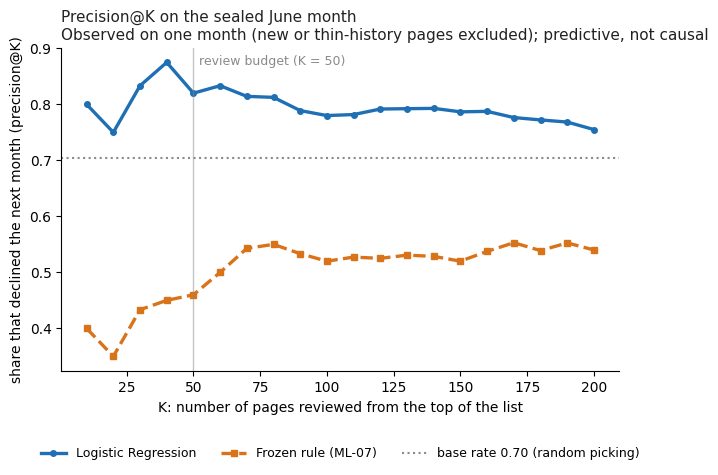

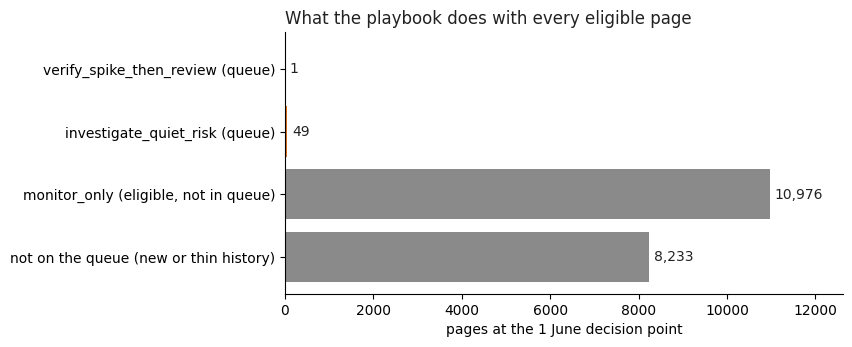

Saved: work/outputs/action_queue.csv (do NOT commit), work/figures/*.png (commit), work/outputs/w07_playbook_metrics.json (commit)


In [7]:
# 5) Exports for the paper: the queue (stays out of git), two figures (commit them), and the metrics receipt (commit it)
import matplotlib.pyplot as plt
EXPORT = queue.rename(columns={"clicks_feb": "clicks_m1", "clicks_mar": "clicks_m2", "clicks_apr": "clicks_m3", "ratio_apr": "ratio_latest_vs_prior", "impressions_apr": "impressions_latest"})
EXPORT[["rank", *KEYS, "action", "reason_code", "confidence", "model_score", "archetype", "clicks_m1", "clicks_m2", "clicks_m3", "ratio_latest_vs_prior", "impressions_latest", "weighted_position", "durable_climb"]].to_csv("work/outputs/action_queue.csv", index=False)
assert not {LABEL, LABEL_NEXT, "clicks_next", "clicks_may"} & set(pd.read_csv("work/outputs/action_queue.csv", nrows=1).columns), "an outcome column leaked into the export"
INK, BLUE, ORANGE, GREY = "#222222", "#1f6fb4", "#d9731a", "#8a8a8a"
if june_ok:
    pop = eval_jun[POP_Q]; ks = list(range(10, 201, 10))
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(ks, [pop["Logistic Regression"]["curve"][k] for k in ks], color=BLUE, lw=2.4, marker="o", ms=4, label="Logistic Regression")
    ax.plot(ks, [pop["Frozen rule"]["curve"][k] for k in ks], color=ORANGE, lw=2.4, ls="--", marker="s", ms=4, label="Frozen rule (ML-07)")
    ax.axhline(pop["base_rate"], color=GREY, lw=1.5, ls=":", label=f"base rate {pop['base_rate']:.2f} (random picking)"); ax.axvline(K_MAIN, color=GREY, lw=1, alpha=.5)
    ax.annotate("review budget (K = 50)", xy=(K_MAIN, 1), xycoords=("data", "axes fraction"), xytext=(4, -12), textcoords="offset points", color=GREY, fontsize=9)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=9)
    ax.set_xlabel("K: number of pages reviewed from the top of the list"); ax.set_ylabel("share that declined the next month (precision@K)")
    ax.set_title("Precision@K on the sealed June month\nObserved on one month (new or thin-history pages excluded); predictive, not causal", color=INK, fontsize=11, loc="left"); ax.spines[["top", "right"]].set_visible(False)
    fig.savefig("work/figures/precision_at_k.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("precision_at_k.png skipped: the June label month could not be read.")
mix = pd.Series({"verify_spike_then_review (queue)": int((queue["action"] == "verify_spike_then_review").sum()), "investigate_quiet_risk (queue)": int((queue["action"] == "investigate_quiet_risk").sum()),
                 "monitor_only (eligible, not in queue)": int(len(elig) - K_MAIN), "not on the queue (new or thin history)": int((jun["archetype"] == A1).sum())})
fig, ax = plt.subplots(figsize=(7.2, 3.4)); ax.barh(mix.index[::-1], mix.values[::-1], color=[GREY, GREY, ORANGE, BLUE])
for i, v in enumerate(mix.values[::-1]): ax.text(v + mix.max() * 0.01, i, f"{v:,}", va="center", fontsize=10, color=INK)
ax.set_xlim(0, mix.max() * 1.15); ax.set_xlabel("pages at the 1 June decision point"); ax.set_title("What the playbook does with every eligible page", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False); fig.savefig("work/figures/action_mix.png", dpi=150, bbox_inches="tight"); plt.show()

json.dump({"seed": SEED, "k": K_MAIN, "frozen_before_june": {"model": "Logistic Regression, 9 contract features, trained at the 1 May point only", "rule": "ML-07", "min_ratio": MIN_RATIO, "history_floor": HISTORY_FLOOR,
           "dip_cut": DIP_CUT, "extreme_jump": SURGE_EXTREME, "low_confidence_clicks": LOW_CLICKS},
           "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
           "training_pages": int(len(dev)), "scoring_pages": int(len(jun)), "identical_block_excluded": {"training": n_block_dev, "scoring": n_block_jun}, "june_label_read": bool(june_ok),
           "queue_action_mix": queue["action"].value_counts().to_dict(), "queue_confidence": queue["confidence"].value_counts().to_dict(),
           "archetypes_dev": tab.reset_index().to_dict("records"), "archetypes_june": (tj.reset_index().to_dict("records") if june_ok else None),
           "sealed_june_evaluation": {k: {n: ({m: (v2 if m != "curve" else {str(kk): vv for kk, vv in v2.items()}) for m, v2 in v.items()} if isinstance(v, dict) else v) for n, v in r.items()} for k, r in eval_jun.items()},
           "psi": psi_tab.reset_index().to_dict("records"), "triggers": triggers, "gates": gates.to_dict("records")},
          open("work/outputs/w07_playbook_metrics.json", "w"), indent=2, default=str)
print("Saved: work/outputs/action_queue.csv (do NOT commit), work/figures/*.png (commit), work/outputs/w07_playbook_metrics.json (commit)")


## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.